**Cell 1 — Imports and configuration**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rankdata
from scipy.ndimage import uniform_filter1d

DATA_DIR = "../Data"
OUTPUT_DIR = os.getcwd()

TICKERS = {
    "Bayer":      "BAYN_DE_price_volume.csv",
    "BMW":        "BMW_DE_price_volume.csv",
    "Siemens":    "SIE_DE_price_volume.csv",
    "Volkswagen": "VOW_DE_price_volume.csv",
}

SCATTER_PAIRS = [
    ("Bayer",   "Siemens"),
    ("BMW",     "Volkswagen"),
    ("Siemens", "Volkswagen"),
]

TDC_PAIRS = [
    ("BMW",     "Volkswagen"),
    ("Siemens", "Volkswagen"),
    ("Bayer",   "Siemens"),
]

**Cell 2 — Load data and compute standardized log-returns**

In [2]:
def load_close(filename):
    path = os.path.join(DATA_DIR, filename)
    s = pd.read_csv(path, parse_dates=["Date"]).set_index("Date")["Close"]
    s.index = pd.to_datetime(s.index, format="%d.%m.%Y")
    return s

def std_log_returns(s):
    lr = np.log(s / s.shift(1)).dropna()
    return (lr - lr.mean()) / lr.std()

returns = {name: std_log_returns(load_close(file)) for name, file in TICKERS.items()}

def align(name1, name2):
    s1, s2 = returns[name1], returns[name2]
    idx = s1.index.intersection(s2.index)
    return s1.loc[idx].values, s2.loc[idx].values

**Cell 3 — Scatter plot function**

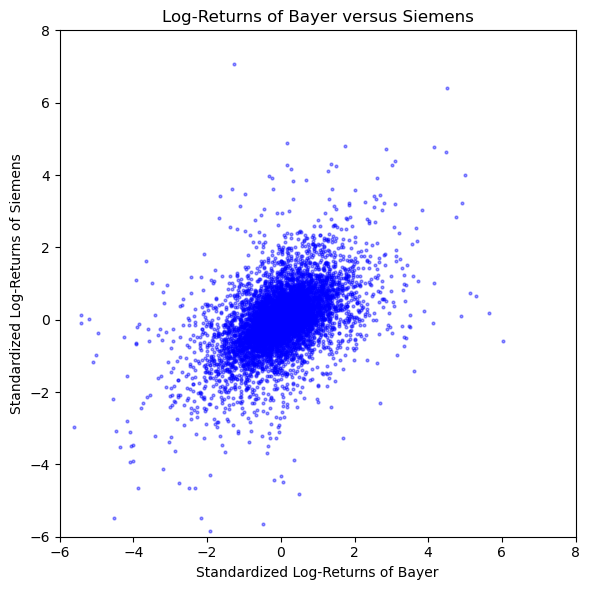

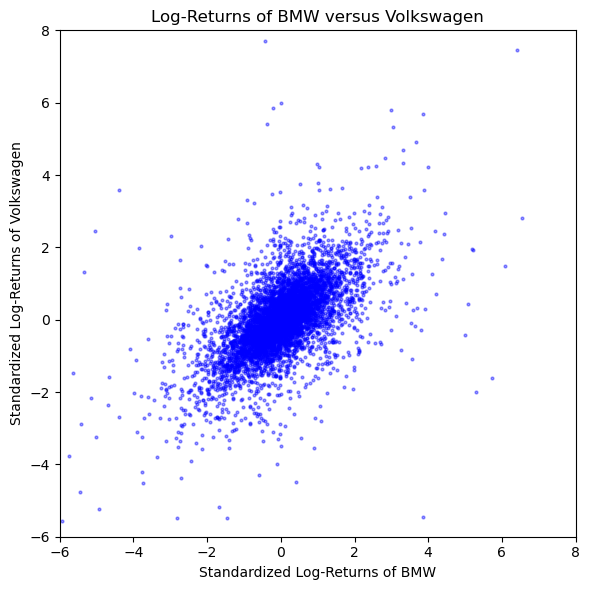

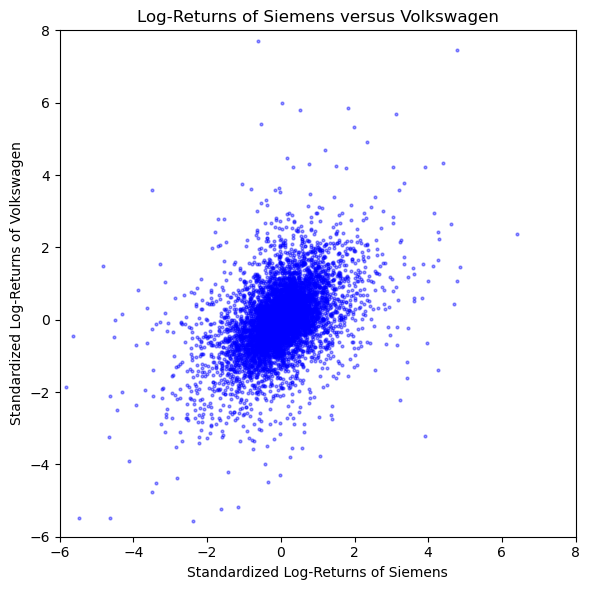

In [3]:
def scatter_pair(name1, name2):
    a, b = align(name1, name2)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(a, b, color="blue", s=4, alpha=0.4)
    ax.set_xlim(-6, 8)
    ax.set_ylim(-6, 8)
    ax.set_xlabel(f"Standardized Log-Returns of {name1}")
    ax.set_ylabel(f"Standardized Log-Returns of {name2}")
    ax.set_title(f"Log-Returns of {name1} versus {name2}")
    ax.grid(False)
    plt.tight_layout()

    fname = f"scatter_{name1[:3].lower()}_{name2[:3].lower()}.png"
    plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=200, transparent=True, bbox_inches="tight")
    plt.show()

for name1, name2 in SCATTER_PAIRS:
    scatter_pair(name1, name2)

**Cell 4 — Lambda path and TDC estimator functions**

In [6]:
def make_lambda_path(a, b, bandwidth=20):
    T = len(a)
    s1 = rankdata(a)
    s2 = rankdata(b)
    lam = np.array([np.sum((s1 > (T - k)) & (s2 > (T - k))) / k for k in range(1, T)])
    return uniform_filter1d(lam, size=bandwidth, mode="nearest")

def msrnonp_utd_coef(a, b, x, title_str="", d=900):
    T = len(a)
    s1 = rankdata(a)
    s2 = rankdata(b)
    lam = np.array([np.sum((s1 > (T - k)) & (s2 > (T - k))) / k for k in range(1, T)])

    n = len(x)
    b_val = int(np.floor(0.005 * n))
    m = int(np.floor(np.sqrt(n - 2 * b_val)))
    std_dev = np.std(x[:n - 2 * b_val], ddof=1)

    k_star = 0
    for k in range(n - m - 2 * b_val + 1):
        if np.sum(np.abs(x[k + 1 : k + m] - x[k])) <= std_dev:
            k_star = k
            break

    lambda_val = np.mean(x[k_star : k_star + m])
    k_chosen = k_star + 1

    fig, ax = plt.subplots(figsize=(9, 5))
    ks = np.arange(1, d + 1)

    ax.plot(ks, lam[:d], color="black", linewidth=0.8, label="Raw lambda(k)")
    ax.plot(ks, x[:d],   color="red",   linewidth=2,   label="Smoothed lambda path")
    ax.axhline(lambda_val, color="blue", linewidth=1.2,
               label=f"$\\hat{{\\lambda}}_U = {lambda_val:.4f}$")

    k_display = min(k_chosen, d)
    ax.axvline(k_display, color="green", linewidth=1.2, linestyle="--")
    ax.set_xlim(-5, d)
    ax.set_ylim(bottom=0)
    ax.set_xlabel("Threshold k")
    ax.set_ylabel("TDC estimator")
    ax.set_title(title_str)
    ax.grid(False)
    plt.tight_layout()

    return lambda_val, k_chosen, fig

**Cell 5 — Run TDC estimation for all pairs**

TDC estimation for BMW & Volkswagen.  ->  k = 174,  lambda_U = 0.3157


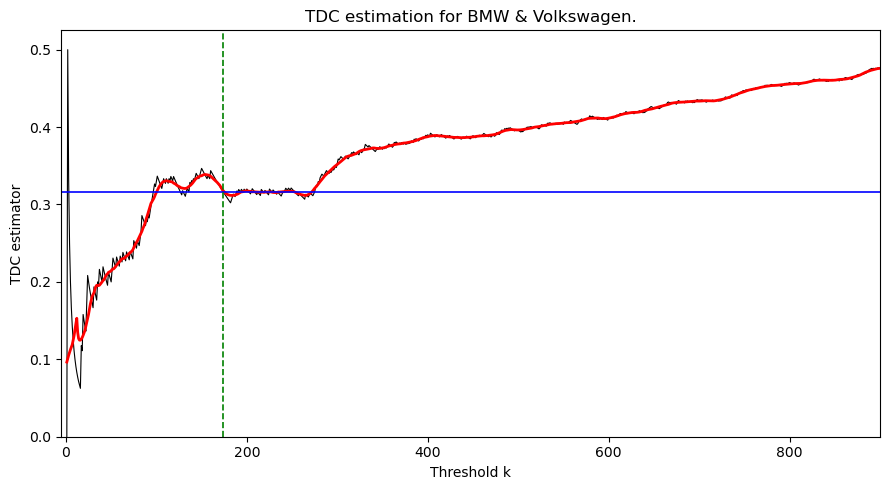

TDC estimation for Siemens & Volkswagen.  ->  k = 308,  lambda_U = 0.2845


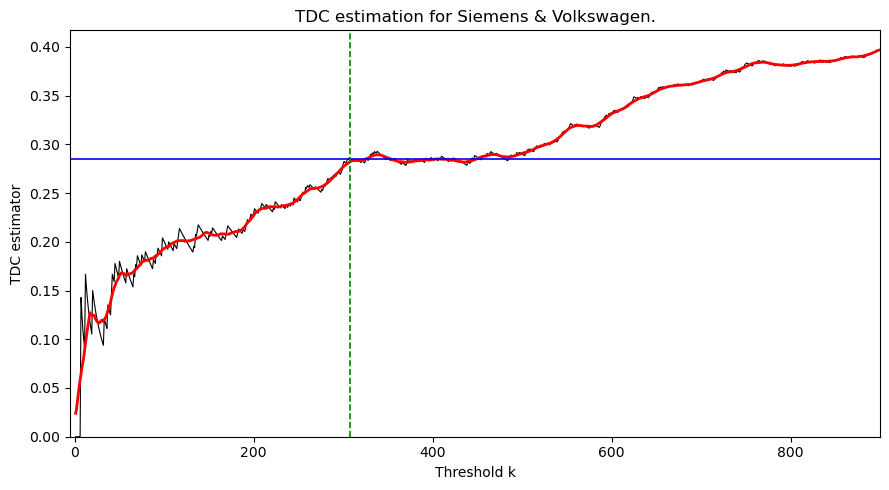

TDC estimation for Bayer & Siemens.  ->  k = 800,  lambda_U = 0.3913


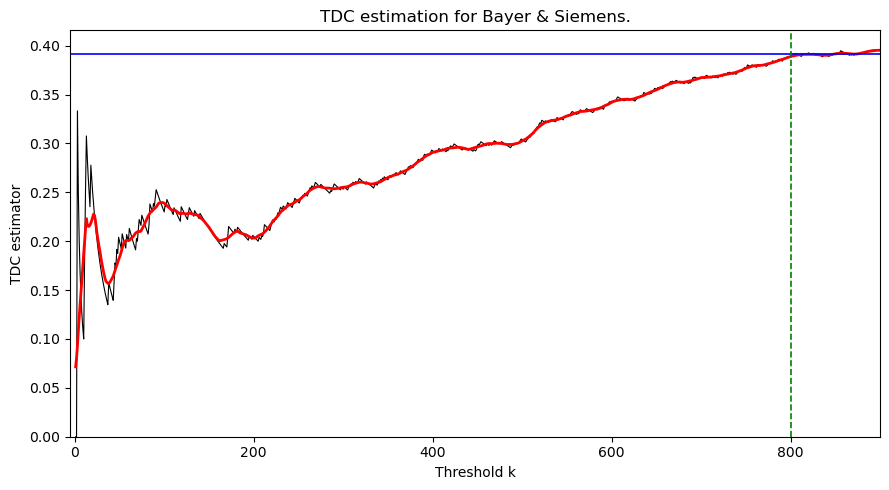

In [7]:
for name1, name2 in TDC_PAIRS:
    a, b = align(name1, name2)
    x = make_lambda_path(a, b, bandwidth=20)
    title = f"TDC estimation for {name1} & {name2}."
    lambda_val, k_chosen, fig = msrnonp_utd_coef(a, b, x, title_str=title)

    print(f"{title}  ->  k = {k_chosen},  lambda_U = {lambda_val:.4f}")

    fname = f"tdc_{name1[:3].lower()}_{name2[:3].lower()}.png"
    fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=200, transparent=True, bbox_inches="tight")
    plt.show()